<a href="https://colab.research.google.com/github/Shorovpaul/Data_Testing/blob/main/Breast_cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
pip install pandas numpy scikit-learn imbalanced-learn shap xgboost

In [10]:
import pandas as pd

data = pd.read_csv("breast_cancer.csv")

print(data.shape)
# Step 1: Rename the column
data.rename(columns={'diagnosis': 'Class'}, inplace=True)

# Drop the 'Unnamed: 32' column if it exists and is full of NaNs
if 'Unnamed: 32' in data.columns:
    data = data.drop(columns=['Unnamed: 32'])

# Step 2: Verify it worked
print(data.columns.tolist())

# Step 3: Now use it
print(data['Class'].value_counts())

(569, 33)
['id', 'Class', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']
Class
B    357
M    212
Name: count, dtype: int64


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X = data.drop("Class", axis=1)
y = data["Class"]

# Encode the target variable 'y' to numerical values
le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [14]:
from imblearn.over_sampling import SMOTE
import pandas as pd # Import pandas to use Series

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Convert y_train_bal to a Pandas Series to use value_counts()
print(pd.Series(y_train_bal).value_counts())

1    285
0    285
Name: count, dtype: int64


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_bal = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import xgboost as xgb

models = {
    "LR": LogisticRegression(max_iter=1000),
    "RF": RandomForestClassifier(n_estimators=200),
    "GB": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "XGB": xgb.XGBClassifier(eval_metric="logloss")
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    trained_models[name] = model

In [17]:
from sklearn.metrics import average_precision_score

model_scores = {}

for name, model in trained_models.items():
    probs = model.predict_proba(X_test_scaled)[:,1]
    score = average_precision_score(y_test, probs)
    model_scores[name] = score

print(model_scores)

{'LR': np.float64(0.9908429288528133), 'RF': np.float64(0.9977701354007973), 'GB': np.float64(0.9982986766270131), 'KNN': np.float64(0.9757390081045613), 'SVM': np.float64(0.9929000055306676), 'XGB': np.float64(0.9948543519972092)}


In [18]:
selected_models = {
    name:model for name,model in trained_models.items()
    if model_scores[name] > 0.70
}

In [20]:
import shap
import numpy as np

explanations = {}

for name, model in selected_models.items():
    # Define a prediction function for SHAP, returning the probability of the positive class
    def f(X):
        return model.predict_proba(X)[:, 1]

    # Use the prediction function with shap.Explainer
    explainer = shap.Explainer(f, X_train_bal[:1000])
    shap_values = explainer(X_train_bal[:1000])

    importance = np.abs(shap_values.values).mean(axis=0)

    explanations[name] = importance

PermutationExplainer explainer: 571it [00:15, 24.64it/s]                         
PermutationExplainer explainer: 571it [04:17,  2.13it/s]
PermutationExplainer explainer: 571it [00:40, 10.46it/s]
PermutationExplainer explainer: 571it [02:25,  3.62it/s]
PermutationExplainer explainer: 571it [05:28,  1.69it/s]
PermutationExplainer explainer: 571it [00:42, 10.38it/s]                         


In [22]:
from sklearn.model_selection import KFold
import numpy as np
import shap # Ensure shap is imported if not already

kf = KFold(n_splits=5)

stability_scores = {}

for name, model in selected_models.items():

    fold_importance = []

    for train_idx, val_idx in kf.split(X_train_bal):

        model.fit(X_train_bal[train_idx], y_train_bal[train_idx]) # Corrected indexing for y_train_bal

        # Define a prediction function for SHAP, returning the probability of the positive class
        def f(X):
            return model.predict_proba(X)[:, 1]

        # Use the prediction function with shap.Explainer
        explainer = shap.Explainer(f, X_train_bal[val_idx][:200])
        shap_values = explainer(X_train_bal[val_idx][:200])

        importance = abs(shap_values.values).mean(axis=0)

        fold_importance.append(importance)

    fold_importance = np.array(fold_importance)

    # Calculate stability: variance of feature importance across folds
    # Small stability_scores indicate higher stability.
    # Using 1 / (1 + variance) makes higher scores mean higher stability.
    stability = 1 / (1 + fold_importance.var(axis=0).mean()) # Calculate variance across features and then mean

    stability_scores[name] = stability

print(stability_scores)

PermutationExplainer explainer: 115it [00:51,  1.78it/s]
PermutationExplainer explainer: 115it [00:48,  1.86it/s]
PermutationExplainer explainer: 115it [00:46,  1.91it/s]
PermutationExplainer explainer: 115it [00:47,  1.90it/s]
PermutationExplainer explainer: 115it [00:42,  2.13it/s]
PermutationExplainer explainer: 115it [00:23,  2.68it/s]
PermutationExplainer explainer: 115it [00:24,  2.83it/s]
PermutationExplainer explainer: 115it [00:24,  2.79it/s]
PermutationExplainer explainer: 115it [00:24,  2.83it/s]
PermutationExplainer explainer: 115it [00:24,  2.83it/s]
PermutationExplainer explainer: 115it [00:59,  1.57it/s]
PermutationExplainer explainer: 115it [00:59,  1.57it/s]
PermutationExplainer explainer: 115it [00:57,  1.62it/s]
PermutationExplainer explainer: 115it [00:58,  1.59it/s]
PermutationExplainer explainer: 115it [01:01,  1.55it/s]


{'LR': np.float64(0.9999060399622629), 'RF': np.float64(0.9999484903818007), 'GB': np.float64(0.9997374713540274), 'KNN': np.float64(0.9999674155153194), 'SVM': np.float64(0.9999445499648346), 'XGB': np.float64(0.9998304521386916)}


In [23]:
from sklearn.metrics.pairwise import cosine_similarity

diversity_scores = {}

names = list(explanations.keys())

for i in range(len(names)):
    for j in range(i+1, len(names)):

        sim = cosine_similarity(
            explanations[names[i]].reshape(1,-1),
            explanations[names[j]].reshape(1,-1)
        )[0][0]

        diversity = 1 - sim

        diversity_scores[(names[i],names[j])] = diversity

print(diversity_scores)

{('LR', 'RF'): np.float64(0.21026012745184908), ('LR', 'GB'): np.float64(0.3279419763930398), ('LR', 'KNN'): np.float64(0.0838494884847405), ('LR', 'SVM'): np.float64(0.06862420760569488), ('LR', 'XGB'): np.float64(0.2481796425890569), ('RF', 'GB'): np.float64(0.16337508822334557), ('RF', 'KNN'): np.float64(0.1422205448421371), ('RF', 'SVM'): np.float64(0.1366847146706135), ('RF', 'XGB'): np.float64(0.1584656123190099), ('GB', 'KNN'): np.float64(0.33360802652537846), ('GB', 'SVM'): np.float64(0.3246124851716248), ('GB', 'XGB'): np.float64(0.057608117929241476), ('KNN', 'SVM'): np.float64(0.013362989815462356), ('KNN', 'XGB'): np.float64(0.25971853131833367), ('SVM', 'XGB'): np.float64(0.24196866885056245)}


In [24]:
final_scores = {}

for name in selected_models:

    performance = model_scores[name]
    stability = stability_scores[name]

    diversity = np.mean([
        v for k,v in diversity_scores.items() if name in k
    ])

    score = (
        0.5 * performance +
        0.3 * stability +
        0.2 * diversity
    )

    final_scores[name] = score

print(final_scores)

{'LR': np.float64(0.8329474941160607), 'RF': np.float64(0.831309858315217), 'GB': np.float64(0.84735640748942), 'KNN': np.float64(0.8211701119463186), 'SVM': np.float64(0.8278434903993425), 'XGB': np.float64(0.8360139345604602)}


In [25]:
top_models = sorted(final_scores, key=final_scores.get, reverse=True)[:3]

In [26]:
from sklearn.ensemble import StackingClassifier

estimators = [(name, selected_models[name]) for name in top_models]

meta_model = LogisticRegression()

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_model
)

stack.fit(X_train_bal, y_train_bal)

StackingClassifier(estimators=[('GB', GradientBoostingClassifier()),
                               ('XGB',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric='logloss',
                                              feature_types=None,
                                              feature_weights=None, gamma=None,
                                              grow_policy=No...
                                              interaction_constraints=None,
                                              learning_rate=None, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=None,
                                              num_parallel_tree=None, ...)),
                               ('LR', LogisticRegression(max_iter=1000))],
                   final_estimator=LogisticRegression())

In [27]:
probs = stack.predict_proba(X_test_scaled)[:,1]

from sklearn.metrics import average_precision_score

auprc = average_precision_score(y_test, probs)

print("Stacked AUPRC:", auprc)

Stacked AUPRC: 0.997467071935157


PermutationExplainer explainer: 115it [00:30,  2.96it/s]
/tmp/ipykernel_726/149009342.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values)


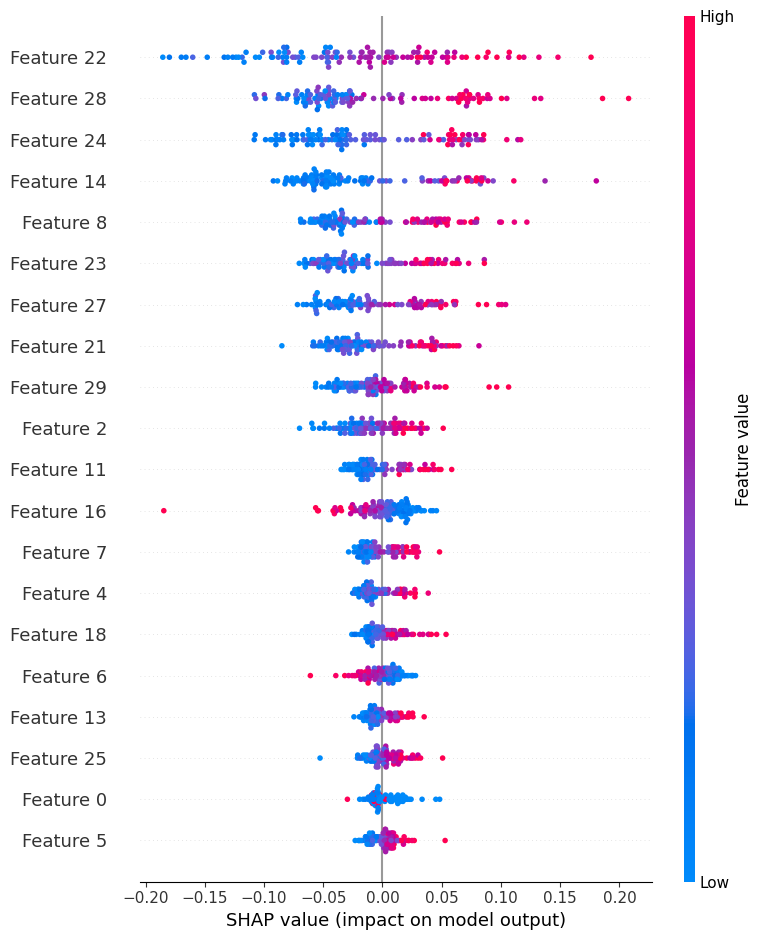

In [30]:
import shap
import numpy as np

def f_stack(X):
    return stack.predict_proba(X)[:, 1]

explainer = shap.Explainer(f_stack, X_train_bal[:1000])
shap_values = explainer(X_test_scaled[:200])

shap.summary_plot(shap_values)